<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/SamuBenjU7proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dynamic Friction Coefficients of Lavender Flowers by Surface Moisture Content, and Sliding Velocity

In [1]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt

In [2]:
!pip install git+https://github.com/pydata/xarray.git
import xarray as xr
!pip install bambi
import bambi as bmb

  Cloning https://github.com/pydata/xarray.git to /tmp/pip-req-build-58qu6gq4
  Running command git clone --filter=blob:none --quiet https://github.com/pydata/xarray.git /tmp/pip-req-build-58qu6gq4
  Resolved https://github.com/pydata/xarray.git to commit 282235f4f3e3432c9defaee45777ecef256d8684
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#Fuel Consumption

I am using a fuel consumption dataset. This data set contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. I will try to predict the how the engine size determines the CO2 emmisions from the engine and other factors that effect this like fuel consumption and cylinders.

In [4]:
url = 'https://raw.githubusercontent.com/sambencoding/Data-Science-Assignments/refs/heads/main/FuelConsumptionCo2.csv'
data = pd.read_csv(url)
data


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [7]:
co2 = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
co2.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


<Axes: xlabel='ENGINESIZE', ylabel='CO2EMISSIONS'>

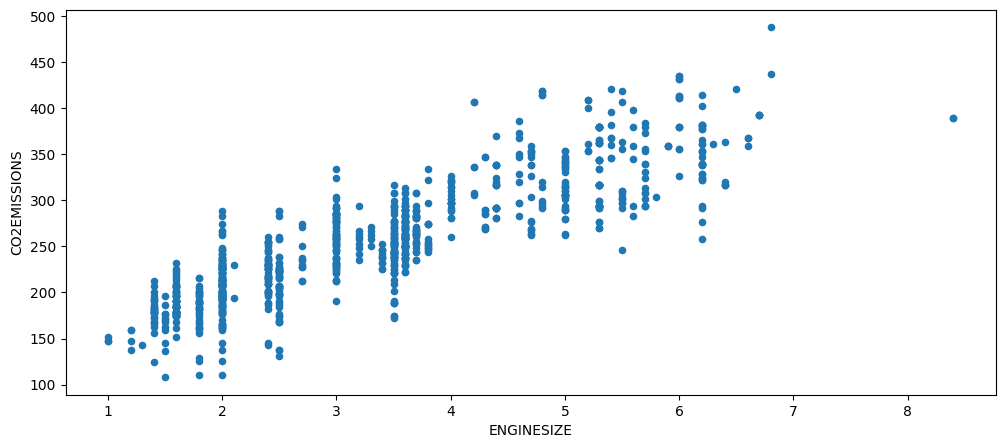

In [13]:
co2.plot(x="ENGINESIZE", y="CO2EMISSIONS", figsize=(12, 5), kind="scatter")

array([[<Axes: xlabel='ENGINESIZE', ylabel='ENGINESIZE'>,
        <Axes: xlabel='CYLINDERS', ylabel='ENGINESIZE'>,
        <Axes: xlabel='FUELCONSUMPTION_COMB', ylabel='ENGINESIZE'>,
        <Axes: xlabel='CO2EMISSIONS', ylabel='ENGINESIZE'>],
       [<Axes: xlabel='ENGINESIZE', ylabel='CYLINDERS'>,
        <Axes: xlabel='CYLINDERS', ylabel='CYLINDERS'>,
        <Axes: xlabel='FUELCONSUMPTION_COMB', ylabel='CYLINDERS'>,
        <Axes: xlabel='CO2EMISSIONS', ylabel='CYLINDERS'>],
       [<Axes: xlabel='ENGINESIZE', ylabel='FUELCONSUMPTION_COMB'>,
        <Axes: xlabel='CYLINDERS', ylabel='FUELCONSUMPTION_COMB'>,
        <Axes: xlabel='FUELCONSUMPTION_COMB', ylabel='FUELCONSUMPTION_COMB'>,
        <Axes: xlabel='CO2EMISSIONS', ylabel='FUELCONSUMPTION_COMB'>],
       [<Axes: xlabel='ENGINESIZE', ylabel='CO2EMISSIONS'>,
        <Axes: xlabel='CYLINDERS', ylabel='CO2EMISSIONS'>,
        <Axes: xlabel='FUELCONSUMPTION_COMB', ylabel='CO2EMISSIONS'>,
        <Axes: xlabel='CO2EMISSIONS', ylabe

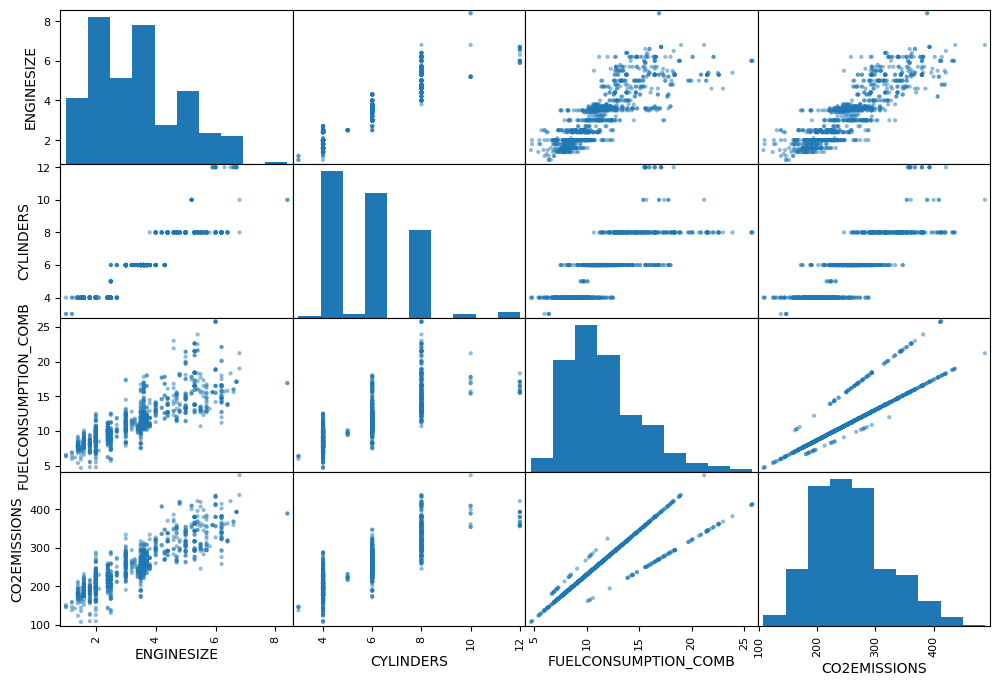

In [15]:
pd.plotting.scatter_matrix(co2, figsize=(12, 8))

In [17]:
model1 = bmb.Model("ENGINESIZE ~ CO2EMISSIONS", data=co2)

# Fit the model
idata_model1 = model1.fit(idata_kwargs={'log_likelihood': True})

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


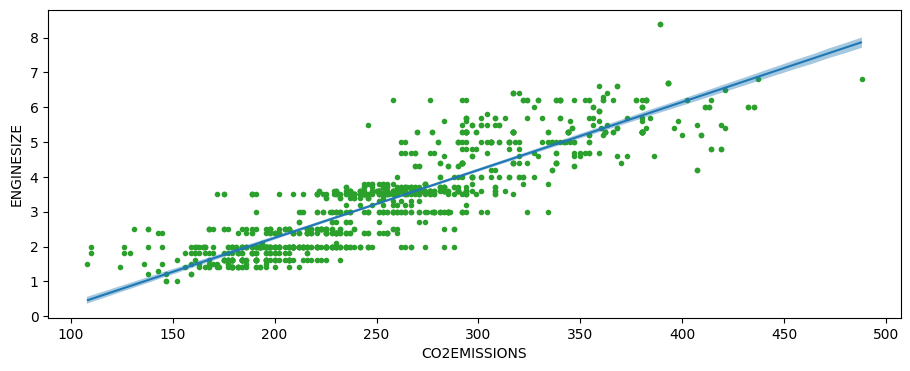

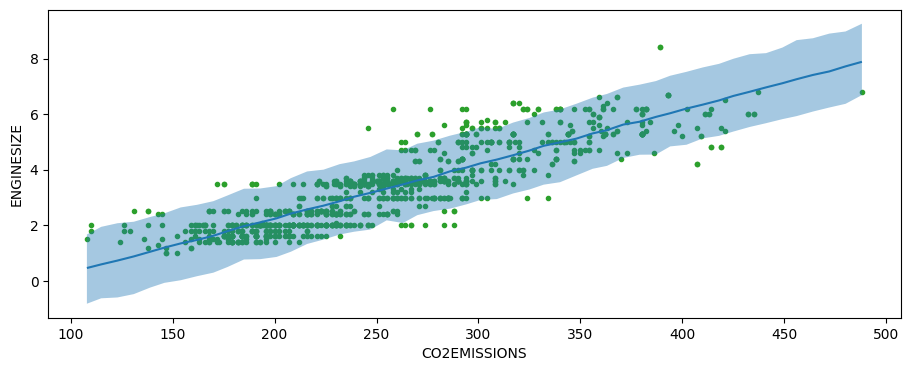

In [20]:
bmb.interpret.plot_predictions(model1, idata_model1, ["CO2EMISSIONS"], fig_kwargs={"figsize":(11, 4)})
plt.plot(co2.CO2EMISSIONS, co2.ENGINESIZE, "C2.", zorder=-3)

bmb.interpret.plot_predictions(model1, idata_model1, ["CO2EMISSIONS"], fig_kwargs={"figsize":(11, 4)}, pps = True)
plt.plot(co2.CO2EMISSIONS, co2.ENGINESIZE, "C2.", zorder=-3)

In [21]:
model2 = bmb.Model("ENGINESIZE ~ CO2EMISSIONS + FUELCONSUMPTION_COMB", data=co2)
#fit the model
idata_model2 = model2.fit(idata_kwargs={'log_likelihood': True})

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


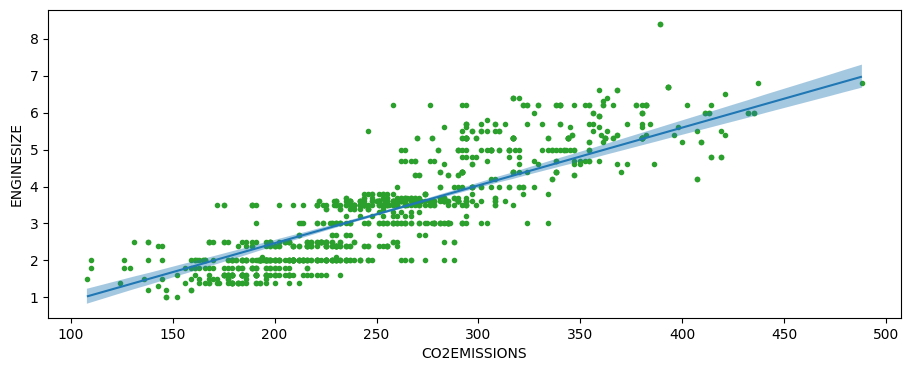

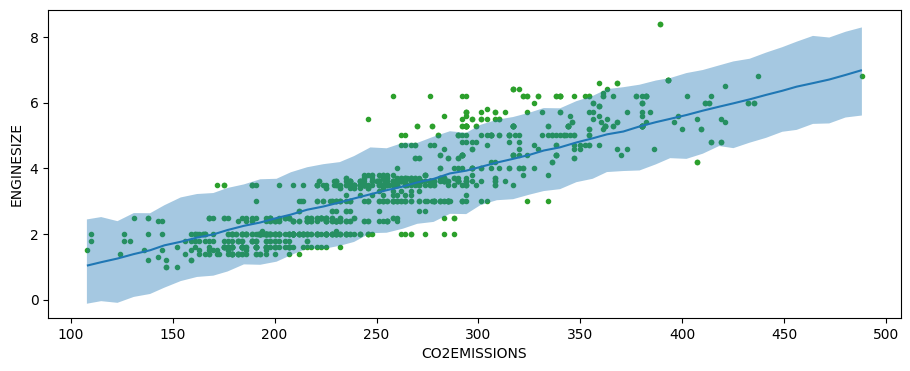

In [22]:
bmb.interpret.plot_predictions(model2, idata_model2, ["CO2EMISSIONS"], fig_kwargs={"figsize":(11, 4)})
plt.plot(co2.CO2EMISSIONS, co2.ENGINESIZE, "C2.", zorder=-3)

bmb.interpret.plot_predictions(model2, idata_model2, ["CO2EMISSIONS"], fig_kwargs={"figsize":(11, 4)}, pps = True)
plt.plot(co2.CO2EMISSIONS, co2.ENGINESIZE, "C2.", zorder=-3)

In [23]:
#define the model
model3 = bmb.Model("ENGINESIZE ~ CO2EMISSIONS + FUELCONSUMPTION_COMB + CYLINDERS", data=co2)
#fit the model
idata_model3 = model3.fit(idata_kwargs={'log_likelihood': True})

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


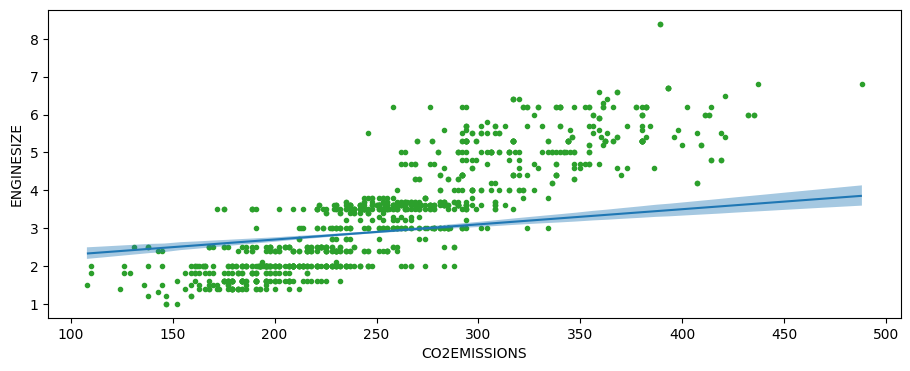

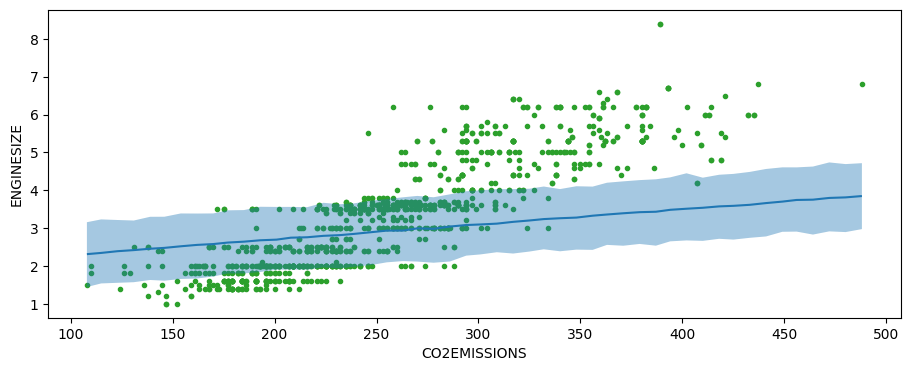

In [24]:
bmb.interpret.plot_predictions(model3, idata_model3, ["CO2EMISSIONS"], fig_kwargs={"figsize":(11, 4)})
plt.plot(co2.CO2EMISSIONS, co2.ENGINESIZE, "C2.", zorder=-3)

bmb.interpret.plot_predictions(model3, idata_model3, ["CO2EMISSIONS"], fig_kwargs={"figsize":(11, 4)}, pps = True)
plt.plot(co2.CO2EMISSIONS, co2.ENGINESIZE, "C2.", zorder=-3)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

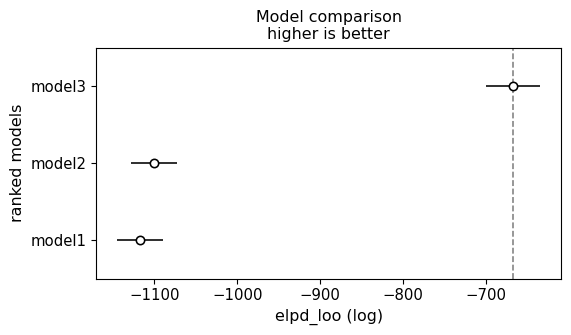

In [25]:
loo_1 = az.loo(idata_model1)
loo_2 = az.loo(idata_model2)
loo_3 = az.loo(idata_model3)

cmp_df = az.compare({"model1":idata_model1, "model2":idata_model2, "model3":idata_model3})
cmp_df
az.plot_compare(cmp_df)

As we can see, models 1 and 2 are very similar and are not as good as model 3. Since model 3 is better than the other models, I will be using that model.

Model 3 is better because it has the highest value among the three models. In Bayesian model comparison, a higher elpd_loo indicates a model that better predicts new data while balancing complexity and fit. Model 1 and Model 2 have significantly lower elpd_loo values, meaning they are less predictive.
Model 3 has the highest elpd_loo value, suggesting it generalizes better and provides the best trade-off between accuracy and complexity.

So this shows that I will be using enginge size versis CO2 emmisions.